In [271]:
import numpy as np
import os
import cv2
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
from torchvision import models, transforms
import torch
from sklearn.metrics import accuracy_score, confusion_matrix
from PIL import Image
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
import pickle
import torchvision.transforms.functional as TF



In [272]:
# setting up paths 
BASE = os.path.abspath(os.path.join(os.getcwd(), os.pardir))

data_path = os.path.join(BASE, "data")

no_defect = os.listdir(os.path.join(data_path, "KGT_noDefect"))
pitting= os.listdir(os.path.join(data_path, "KGT_pitting"))

<h1>Data Inspection </h1>

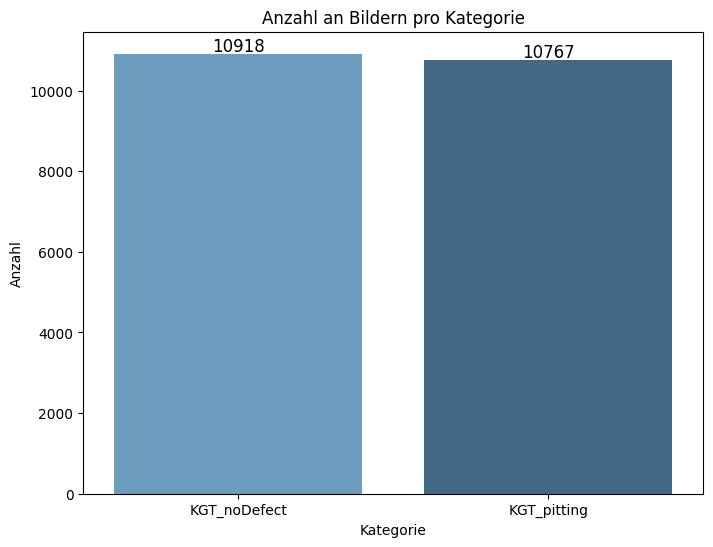

21685


In [261]:
df = pd.DataFrame({
    'Folder': ['KGT_noDefect', 'KGT_pitting'],
    'File Count': [len(no_defect), len(pitting)]
})

plt.figure(figsize=(8, 6))
barplot = sns.barplot(x='Folder', y='File Count', hue="Folder",data=df, palette='Blues_d', legend=False)

plt.title('Anzahl an Bildern pro Kategorie')
plt.xlabel('Kategorie')
plt.ylabel('Anzahl')

for p in barplot.patches:
    barplot.annotate(f'{int(p.get_height())}', 
                      (p.get_x() + p.get_width() / 2., p.get_height()), 
                      ha='center', va='center', 
                      fontsize=12, color='black', 
                      xytext=(0, 5), textcoords='offset points')

plt.show()

sum = len(no_defect) + len(pitting)
print(sum)

In [19]:
img_path = os.path.join(data_path, "KGT_noDefect", no_defect[0])

img = Image.open(img_path)

img.mode

'RGB'

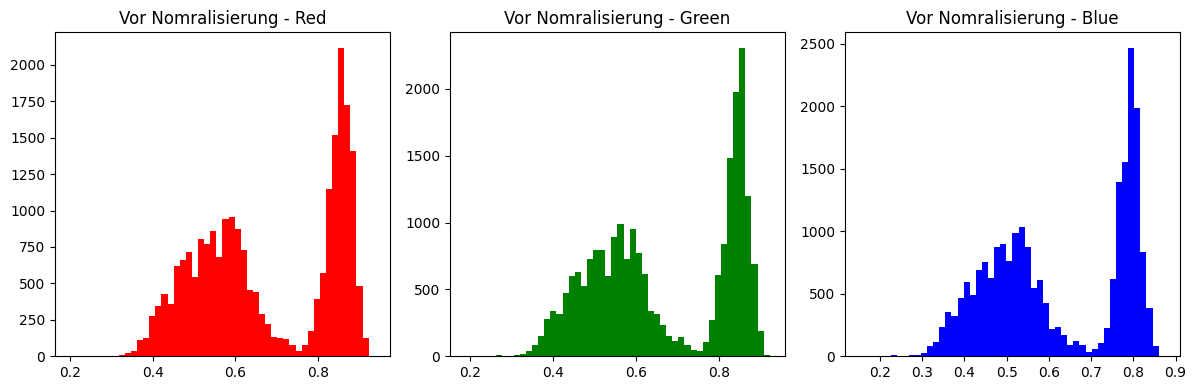

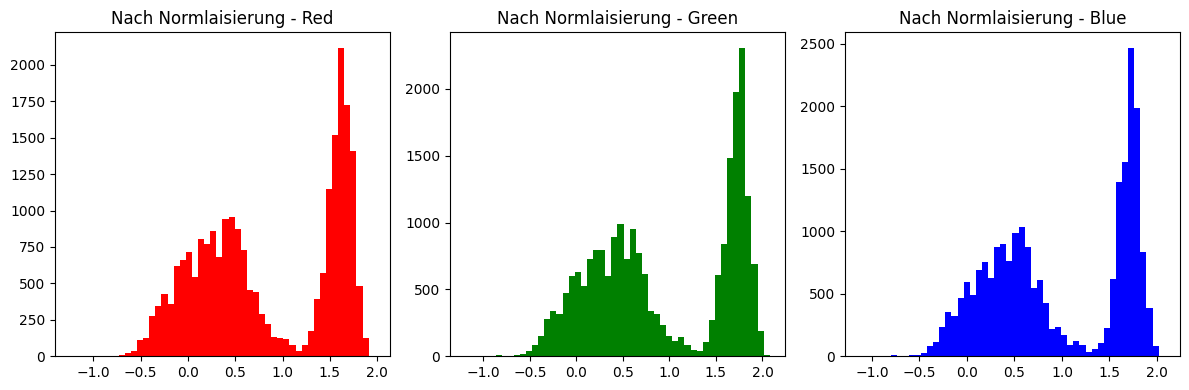

In [264]:
# Define transforms
to_tensor = transforms.ToTensor()
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406], #values used in pretraining 
    std=[0.229, 0.224, 0.225]
)

# Apply transformations
tensor_img = to_tensor(img)
normalized_img = normalize(tensor_img)

# Plot histograms
def plot_histogram(tensor, title):
    plt.figure(figsize=(12, 4))
    channels = ['Red', 'Green', 'Blue']
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.hist(tensor[i].flatten().numpy(), bins=50, color=channels[i].lower())
        plt.title(f'{title} - {channels[i]}')
    plt.tight_layout()
    plt.show()

plot_histogram(tensor_img, "Vor Nomralisierung")
plot_histogram(normalized_img, "Nach Normlaisierung")

<h1> Model Training <h1>

In diesem Abschnitt implementieren wir ein vortrainiertes Convolutional Neural Network (CNN) und passen es an unseren Datensatz an (Finetuning). Dabei verwenden wir ResNet-18 von Microsoft, ein bewährtes Modell, das in unserem Bericht ausführlicher beschrieben wird.
Zur Untersuchung des Einflusses von Datenaugmentation werden die Eingabebilder in drei Varianten verarbeitet: zunächst mit minimalen Transformationen, anschließend mit moderater und schließlich mit starker Augmentierung. Die Ergebnisse dieser drei Varianten vergleichen wir anschließend hinsichtlich ihrer Modell-Performance.

### Transformationspipeline für Trainingsdaten

Diese Bildtransformationen werden verwendet, um das Modell robuster und generalisierungsfähiger zu machen:

- **Resize(256)**: Skaliert die kürzeste Seite des Bildes auf 256 Pixel, um eine einheitliche Ausgangsgröße zu schaffen.
- **RandomResizedCrop(224)**: Schneidet zufällig einen Bereich aus dem Bild aus und skaliert ihn auf 224×224 Pixel. Dies simuliert verschiedene Zoom- und Zuschnittsituationen. Die Größe von 224x224 Pixel wurde gewählt, da ResNet, so wie viele andere (vortrainierte) CNN diese Inputgröße erwarten
- **RandomHorizontalFlip()**: Spiegelt das Bild zufällig horizontal (mit 50 % Wahrscheinlichkeit), um Symmetrie zu nutzen.
- **ColorJitter**:
  - `brightness=0.2`: Zufällige Helligkeit (±20 %)
  - `contrast=0.2`: Zufälliger Kontrast (±20 %)
  - `saturation=0.2`: Zufällige Farbsättigung (±20 %)
  - `hue=0.05`: Zufälliger Farbton (±5 %)
  Diese Veränderung der Farben erhöht die Vielfalt künstlich.
- **RandomRotation(10)**: Rotiert das Bild zufällig im Bereich von ±10°, um leichte Schräglagen zu simulieren.
- **ToTensor()**: Konvertiert das PIL-Bild in einen PyTorch-Tensor im Format **CHW** (`[Channels, Height, Width]`) und skaliert die Werte in den Bereich [0.0, 1.0].
- **Normalize(mean, std)**: Wendet eine Normalisierung mit den **ImageNet-Statistiken** an (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`), damit das Modell die gleichen Datenverteilungen wie beim Pretraining sieht.

> Ziel: Diese Pipeline hilft dem Modell, sich nicht auf bestimmte Bildpositionen, -farben oder -ausrichtungen zu verlassen und dadurch robuster zu werden.


<h2> Festlgung der Transformationen </h2>

Für die Trainings-/Validierungs-Daten wurde eine andere Transformation gewählt als für die Test-Daten. Der Grund hierfür ist, dass das Laden der Daten aus dem jeweiligen Datensatz lazy passiert. Die Daten werden nicht vor dem Laden in den definierten Test-Datenstz transformiert, sondern erst wenn sie tatsächlich gebracht werden. Damit ist das Laden von Bilddaten (Tensoren) aufgrund der stochastischen Operationen (RandomReistedCrop, RandomHorizontalFlip etc.) nicht deterministisch, wodurch die Performance-Metrics bei mehrfachem Testen leicht unterschiedlch wären. Deshalb definieren wir für den Testdatensatz deterministische Transformatoren, um Replizierbarkeit zu gewährleisten. Auf diesen Aspekt werden wir genauer im Bericht eingehen. 

In [ ]:
# Training & Validierung 

# Light
train_transform_light = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Medium
train_transform_medium = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Strong
train_transform_strong = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05
    ),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Test 

# Light
test_transform_light = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Medium
test_transform_medium = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ColorJitter(
        brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Strong
test_transform_strong = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# Datensätze separat laden

def load_full_datasets(transformation: str): 
    transform = {
        "light" : [train_transform_light, test_transform_light], 
        "medium" : [train_transform_medium, test_transform_medium], 
        "strong" : [train_transform_strong, test_transform_strong]
    }
    full_dataset_train_val = datasets.ImageFolder(
        root=os.path.join(BASE, "dataset"), transform=transform[transformation][0])

    full_dataset_test = datasets.ImageFolder(
        root=os.path.join(BASE, "dataset"), transform=transform[transformation][1])
    
    return full_dataset_train_val, full_dataset_test


In [ ]:
full_dataset_train_val_light, full_dataset_test_light = load_full_datasets("light")
full_dataset_train_val_medium, full_dataset_test_medium = load_full_datasets("medium")
full_dataset_train_val_strong, full_dataset_test_strong = load_full_datasets("strong")

In [ ]:

def make_split(train_val, test): 

    # Aufteilen
    total_size = len(train_val)
    train_size = int(0.7 * total_size)
    val_size = int(0.15 * total_size)
    test_size = total_size - train_size - val_size

    # Split-Indices
    generator = torch.Generator().manual_seed(42)
    train_val_indices = torch.randperm(total_size, generator=generator)

    # Subsets (verwende die gleichen Indices!)
    train_indices = train_val_indices[:train_size]
    val_indices = train_val_indices[train_size:train_size + val_size]
    test_indices = train_val_indices[train_size + val_size:]

    # Trainings- & Validierungssets mit augmentierten Daten
    train_dataset = torch.utils.data.Subset(train_val, train_indices)
    val_dataset = torch.utils.data.Subset(train_val, val_indices)

    # Testset mit deterministischen Daten
    test_dataset = torch.utils.data.Subset(test, test_indices)

    return train_dataset, val_dataset, test_dataset

In [ ]:
train_set_light, val_set_light, test_set_light = make_split(full_dataset_train_val_light, full_dataset_test_light)
train_set_medium, val_set_medium, test_set_medium = make_split(full_dataset_train_val_medium, full_dataset_test_medium)
train_set_strong, val_set_strong, test_set_strong = make_split(full_dataset_train_val_strong, full_dataset_test_strong)

In [ ]:
def make_loader(train_set, val_set, test_set): 
    train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=16, shuffle=False)

    return train_loader, val_loader, test_loader

In [ ]:
train_loader_light, val_loader_light, test_loader_light = make_loader(train_set_light, val_set_light, test_set_light)
train_loader_medium, val_loader_medium, test_loader_medium = make_loader(train_set_medium, val_set_medium, test_set_medium)
train_loader_strong, val_loader_strong, test_loader_strong = make_loader(train_set_strong, val_set_strong, test_set_strong)

In [308]:
model = models.resnet18(pretrained=True)

# Modify the final layer for binary classification
model.fc = nn.Linear(model.fc.in_features, 2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

/Users/janikwahrheit/anaconda3/envs/pitting_env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/janikwahrheit/anaconda3/envs/pitting_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
def save_model(model, transformation): 
    torch.save(model.state_dict(), os.path.join(BASE, "models",  f"resnet18_pitting_not_simplified_{transformation}.pth"))

def save_losses(train_losses: list, val_losses: list, transformation: str): 
    losses = {
        "train": train_losses, 
        "val": val_losses
    }

    # path 
    save_path = os.path.join(BASE, "models", f"losses_{transformation}.pkl")

    # save
    with open(save_path, "wb") as f:
        pickle.dump(losses, f)



def train_model(model, train_loader, val_loader, transformation: str): 

    # Training loop with validation
    num_epochs = 10
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        train_losses.append(running_train_loss)

        # Validation loop
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()

        val_losses.append(running_val_loss)

        print(f"Epoch {epoch+1} | Train Loss: {running_train_loss:.4f} | Val Loss: {running_val_loss:.4f}")

        save_model(model, transformation)
        save_losses(train_losses, val_losses, transformation)

    return model



Epoch 1 | Train Loss: 244.6995 | Val Loss: 37.2498
Epoch 2 | Train Loss: 178.3819 | Val Loss: 35.8805
Epoch 3 | Train Loss: 165.4939 | Val Loss: 25.6682
Epoch 4 | Train Loss: 144.9663 | Val Loss: 23.5624
Epoch 5 | Train Loss: 129.3962 | Val Loss: 21.3502
Epoch 6 | Train Loss: 127.7000 | Val Loss: 21.6549
Epoch 7 | Train Loss: 121.7070 | Val Loss: 20.7866
Epoch 8 | Train Loss: 119.7658 | Val Loss: 20.1639
Epoch 9 | Train Loss: 112.0299 | Val Loss: 21.6800
Epoch 10 | Train Loss: 103.2297 | Val Loss: 23.0577


In [ ]:
# Save model
torch.save(model.state_dict(), os.path.join(BASE, "models",  "resnet18_pitting_not_simplified.pth"))

In [319]:
def plot_losses(losses, transformation):
    epochs = list(range(1, len(losses["train"]) + 1))
    
    df = pd.DataFrame({
        "Epoche": epochs * 2,
        "Loss": losses["train"] + losses["val"],
        "Typ": ["Training"] * len(epochs) + ["Validierung"] * len(epochs)
    })
    
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x="Epoche", y="Loss", hue="Typ", style="Typ", markers=True, dashes=False)

    plt.title(f"Verlust (Loss) pro Epoche | Transformation: {transformation}", fontsize=14)
    plt.xlabel("Epoche", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(title="Datentyp", loc="upper right")
    plt.tight_layout()
    plt.show()

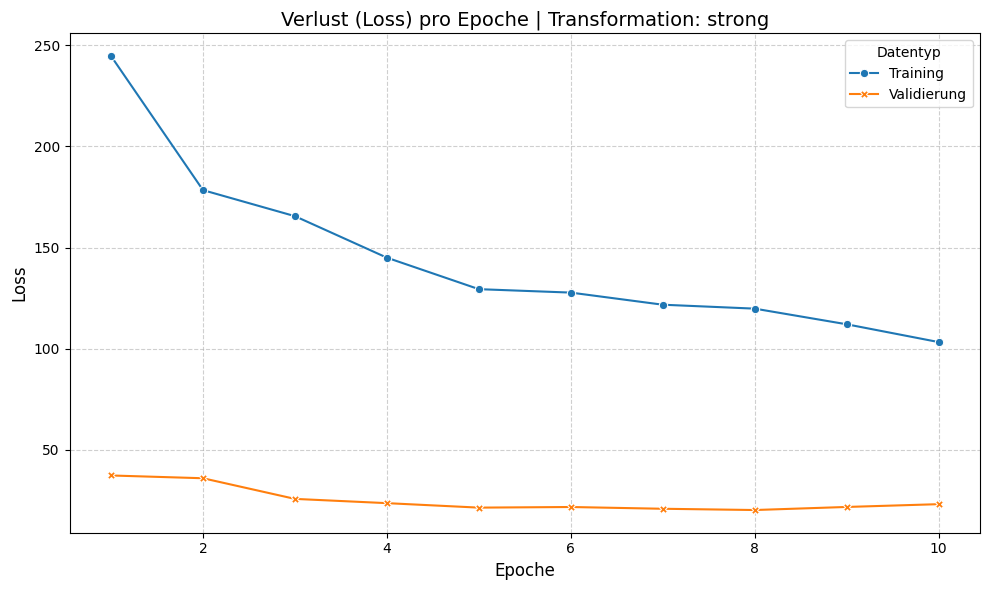

In [320]:
testfig = plot_losses(losses, "strong")

In [ ]:
#load model
def load_model(path): 
    model = models.resnet18(pretrained=False)
    model.fc = torch.nn.Linear(model.fc.in_features, 2)  # 2 classes
    model.load_state_dict(torch.load(path))
    model.to(device) 
    return model 


/Users/janikwahrheit/anaconda3/envs/pitting_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

<h1> Testing </h1> 

In [ ]:
def test_model(model, test_loader): 
    model.eval() 
    # Final evaluation on the test set
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("Test Accuracy:", accuracy_score(all_labels, all_preds))
    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds)) 
    
    y_true = all_labels
    y_pred = all_preds

    sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt="d", cmap="Blues") 


    # Metrics
    print("Test Accuracy:", accuracy_score(y_true, y_pred))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))# Set to evaluation mode for inference


def test_model(model, test_loader, class_names=None, return_metrics=False):

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # metrics
    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, digits=4)

    print(f"Test Accuracy: {acc:.4f}")
    print("\n Classification Report:")
    print(report)

    # Confusion matrix 
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Vorhergesagte Klasse")
    plt.ylabel("Wahre Klasse")
    plt.title("Konfusionsmatrix")
    plt.tight_layout()
    plt.show()

    if return_metrics:
        return acc, cm, report

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

<h1> Visualisierung </h1>

In [305]:
for i in range(100): 
    image_tensor, label = test_dataset[i] 
    if label == 0: 
        print(i)
        break 

4


In [301]:
image_tensor, label = test_dataset[413] 
label

1

In [ ]:
image_tensor2 = image_tensor

In [ ]:
image_tensor.size()
image_tensor_batched = image_tensor.unsqueeze(0)
image_tensor_batched


tensor([[[[-1.3987, -1.3130, -1.2103,  ...,  1.4783,  1.5125,  1.5810],
          [-1.3987, -1.3302, -1.2274,  ...,  1.4440,  1.4783,  1.5125],
          [-1.2959, -1.2788, -1.2103,  ...,  1.4440,  1.4440,  1.4783],
          ...,
          [-0.1999, -0.0629,  0.0569,  ...,  1.4954,  1.5297,  1.5297],
          [-0.1657, -0.0458,  0.0569,  ...,  1.5125,  1.5468,  1.5639],
          [-0.0801,  0.0056,  0.0912,  ...,  1.5297,  1.5639,  1.5810]],

         [[-1.3880, -1.3004, -1.1954,  ...,  1.5357,  1.5882,  1.6408],
          [-1.3880, -1.3179, -1.2129,  ...,  1.5182,  1.5532,  1.6057],
          [-1.2829, -1.2654, -1.1954,  ...,  1.5182,  1.5532,  1.5707],
          ...,
          [-0.2325, -0.0924,  0.0301,  ...,  1.5532,  1.5882,  1.5882],
          [-0.1975, -0.0749,  0.0301,  ...,  1.5707,  1.6057,  1.6232],
          [-0.1099, -0.0224,  0.0651,  ...,  1.5882,  1.6232,  1.6408]],

         [[-1.2641, -1.1770, -1.0724,  ...,  1.5420,  1.5942,  1.6465],
          [-1.2641, -1.1944, -

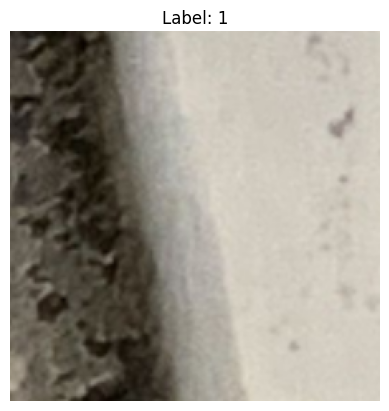

In [302]:
# Unnormalize the image (reverse the normalization applied in the transform)
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])
unnormalized_image = image_tensor * std[:, None, None] + mean[:, None, None]

# Convert to NumPy and transpose for matplotlib (C x H x W -> H x W x C)
image_np = unnormalized_image.permute(1, 2, 0).numpy()

# Display the image
plt.imshow(image_np)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

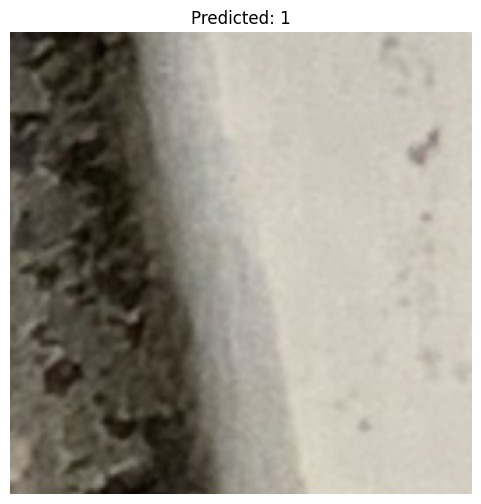

In [ ]:
# Load the image
#image_path = os.path.join(BASE, "data/KGT_pitting_simplified/P (652).png") 
image_path= "/Users/janikwahrheit/Library/CloudStorage/OneDrive-Persönlich/01_Studium/01_Bachelor/06. SS_2025/Pitting_Detection/dataset/KGT_pitting/P (2857).png"

#image_path= "/Users/janikwahrheit/Downloads/Oel_pit_h.jpg"
image = Image.open(image_path)


# Apply the transformations
#image_tensor = test_transform(image).unsqueeze(0)  # Add batch dimension (1, C, H, W)

# Move the image to the same device as the model
image_tensor_batched = image_tensor_batched.to(device)

# Make the prediction
with torch.no_grad():  # Turn off gradients to save memory
    outputs = model(image_tensor_batched)

# Get the predicted class (the index of the max value in the output)
_, predicted_class = torch.max(outputs, 1)


# Display the image and the predicted label
plt.figure(figsize=(6, 6))
#plt.imshow(np.array(image)) 
plt.imshow(image_np) # Convert the image to a numpy array for displaying
plt.title(f'Predicted: {predicted_class.item()}')
plt.axis('off')  
plt.show()

In [ ]:
print(heatmap.shape, image_np.shape)
overlay

(224, 224, 3) (224, 224, 3)


array([[[ 51,   0,   0],
        [ 51,   0,   0],
        [ 51,   0,   0],
        ...,
        [ 58,   0,   0],
        [ 58,   0,   0],
        [ 58,   0,   0]],

       [[ 51,   0,   0],
        [ 51,   0,   0],
        [ 51,   0,   0],
        ...,
        [ 58,   0,   0],
        [ 58,   0,   0],
        [ 58,   0,   0]],

       [[ 51,   0,   0],
        [ 51,   0,   0],
        [ 51,   0,   0],
        ...,
        [ 58,   0,   0],
        [ 58,   0,   0],
        [ 58,   0,   0]],

       ...,

       [[ 51,   0,   0],
        [ 51,   0,   0],
        [ 51,   0,   0],
        ...,
        [102,  40,   0],
        [102,  40,   0],
        [102,  40,   0]],

       [[ 51,   0,   0],
        [ 51,   0,   0],
        [ 51,   0,   0],
        ...,
        [102,  40,   0],
        [102,  40,   0],
        [102,  40,   0]],

       [[ 51,   0,   0],
        [ 51,   0,   0],
        [ 51,   0,   0],
        ...,
        [102,  40,   0],
        [102,  40,   0],
        [102,  40,   0]]

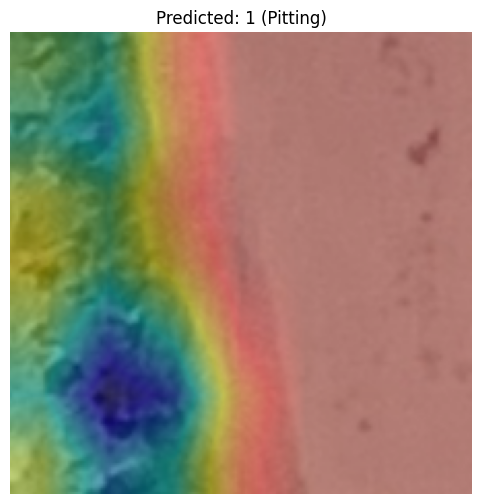

In [ ]:
"""
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]) 
])"""

input_tensor = test_transform(image).unsqueeze(0).to(device)
#Hook for gradients
gradients = []




def save_gradient(grad):
    gradients.append(grad)

#Forward hook for activations
activations = []

def forward_hook(module, input, output):
    activations.append(output)
    output.register_hook(save_gradient)

# Register the hook to the last conv layer of ResNet18
target_layer = model.layer4
hook = target_layer.register_forward_hook(forward_hook)

# Forward pass
output = model(image_tensor_batched)
pred_class = output.argmax(dim=1).item()

#Backward pass for Grad-CAM 
model.zero_grad()
output[0, pred_class].backward()

# Get activations and gradients 
grads_val = gradients[0][0].cpu().detach().numpy()  # (C, H, W)
acts_val = activations[0][0].cpu().detach().numpy()  # (C, H, W)

# Compute the weights and CAM
weights = np.mean(grads_val, axis=(1, 2))  # Global average pooling
cam = np.zeros(acts_val.shape[1:], dtype=np.float32)

for i, w in enumerate(weights):
    cam += w * acts_val[i, :, :]

#Normalize and resize the CAM 
cam = np.maximum(cam, 0)  # ReLU
cam = cam - cam.min()
cam = cam / cam.max()
cam = cv2.resize(cam, (224, 224))

# Overlay the heatmap on the image 
#img_np = np.array(image.resize((224, 224)))  # Original image
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
inverted_heatmap = cv2.bitwise_not(heatmap)
image_uint8 = (image_np * 255).astype(np.uint8)
overlay = heatmap * 0.4 + image_uint8 * 0.6
overlay = np.uint8(overlay)

# Show the result 
plt.figure(figsize=(6, 6))
plt.imshow(overlay)
plt.title(f"Predicted: {pred_class} ({'Pitting' if pred_class == 1 else 'No Defect'})")
plt.axis('off')
plt.show()

# Cleanup
hook.remove()